In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from scipy.stats import invwishart
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns

In [95]:
data = pd.read_csv("Scores_without_covariates", sep = " ")

In [249]:
nu0 = 1
eta0 = 1
mu0 = 50
s20 = 100
t20 = 100
g20 = 25

m = len(data.school.unique())
n, sv, ybar = np.zeros((m)), np.zeros((m)), np.zeros((m))

#starting values

for j in range(1, m+1):
    ybar[j-1] = (data.loc[data.school == j]["mathscore"]).mean()
    sv[j-1] = (data.loc[data.school == j]["mathscore"]).var()
    n[j-1] = (data.loc[data.school == j]["mathscore"]).count()

theta = np.copy(ybar)
sigma2 = sv.mean()
mu = theta.mean()
tau2 = theta.var()

#MCMC
#random.seed(1)
S = 5000
TH = np.zeros((S, m))
SMT = np.zeros((S, 3))

for s in range(S):
    #theta
    for j in range(m):
        vtheta = 1/((n[j]/sigma2) + (1/tau2))
        etheta = vtheta * (ybar[j] * n[j]/sigma2 + mu/tau2)
        theta[j] = np.random.normal(etheta, np.sqrt(vtheta))
    
    #sigma 2
    nun = nu0 + n.sum()
    ss = nu0 * s20
    for j in range(m):
        ss = ss + ((data.loc[data.school == (j+1)]["mathscore"]-theta[j])**2).sum()
    sigma2 = 1/np.random.gamma(nun/2, 2/ss)
    
    #mu
    vmu = 1/(m/tau2 + 1/g20)
    emu = vmu*(m*theta.mean()/tau2 + mu0/g20)
    mu = np.random.normal(emu, np.sqrt(vmu))
    
    #tau2
    etam = eta0 + m
    ss = eta0*t20 + ((theta-mu)**2).sum()
    tau2 = 1/np.random.gamma(etam/2, 2/ss)
    
    #results
    TH[s,:] = theta
    SMT[s,0] = sigma2
    SMT[s,1] = mu
    SMT[s,2] = tau2

In [260]:
np.mean(TH[:,50], axis = 0)

61.83134918704098

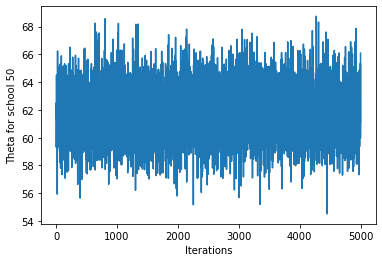

In [126]:
plt.plot(TH[:,50])
plt.xlabel("Iterations")
plt.ylabel("Theta for school 50")
plt.show()

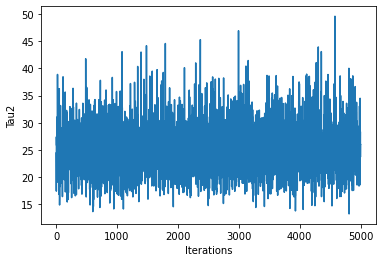

In [129]:
plt.plot(SMT[:,2])
plt.xlabel("Iterations")
plt.ylabel("Tau2")
plt.show()

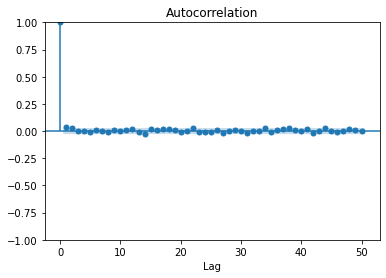

In [261]:
from statsmodels.graphics.tsaplots import plot_acf

# samples is a numpy array containing the samples from the Gibbs sampler
plot_acf(TH[:,50], lags=50)
plt.xlabel("Lag")
plt.show()

<AxesSubplot:ylabel='Density'>

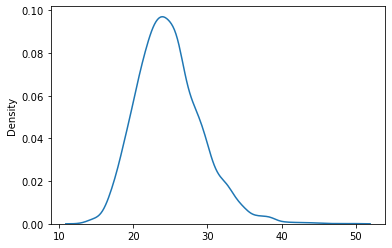

In [140]:
sns.kdeplot(SMT[:,2])

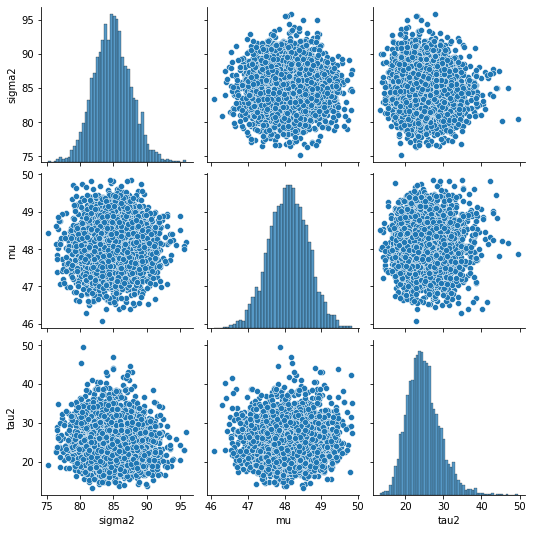

In [148]:
sns.pairplot(pd.DataFrame(SMT, columns=("sigma2","mu","tau2")))

In [157]:
#With different starting values 

nu0 = 5 #1
eta0 = 5 #1
mu0 = 0 #50
s20 = 50 #100
t20 = 50 #100
g20 = 5 #25

m = len(data.school.unique())
n, sv, ybar = np.zeros((m)), np.zeros((m)), np.zeros((m))

#starting values

for j in range(1, m+1):
    ybar[j-1] = (data.loc[data.school == j]["mathscore"]).mean()
    sv[j-1] = (data.loc[data.school == j]["mathscore"]).var()
    n[j-1] = (data.loc[data.school == j]["mathscore"]).count()

theta = np.zeros((m))
sigma2 = 50
mu = 0
tau2 = 50

#MCMC
S = 5000
TH = np.zeros((S, m))
SMT = np.zeros((S, 3))

for s in range(S):
    #theta
    for j in range(m):
        vtheta = 1/((n[j]/sigma2) + (1/tau2))
        etheta = vtheta * (ybar[j] * n[j]/sigma2 + mu/tau2)
        theta[j] = np.random.normal(etheta, np.sqrt(vtheta))
    
    #sigma 2
    nun = nu0 + n.sum()
    ss = nu0 * s20
    for j in range(m):
        ss = ss + ((data.loc[data.school == (j+1)]["mathscore"]-theta[j])**2).sum()
    sigma2 = 1/np.random.gamma(nun/2, 2/ss)
    
    #mu
    vmu = 1/(m/tau2 + 1/g20)
    emu = vmu*(m*theta.mean()/tau2 + mu0/g20)
    mu = np.random.normal(emu, np.sqrt(vmu))
    
    #tau2
    etam = eta0 + m
    ss = eta0*t20 + ((theta-mu)**2).sum()
    tau2 = 1/np.random.gamma(etam/2, 2/ss)
    
    #results
    TH[s,:] = theta
    SMT[s,0] = sigma2
    SMT[s,1] = mu
    SMT[s,2] = tau2

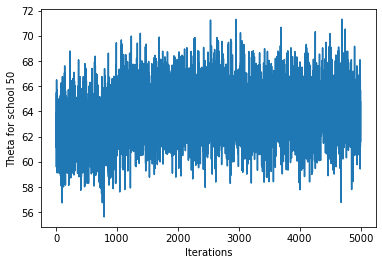

In [158]:
plt.plot(TH[:,50])
plt.xlabel("Iterations")
plt.ylabel("Theta for school 50")
plt.show()

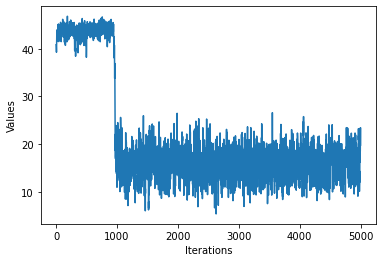

In [165]:
plt.plot(SMT[:,1])
plt.xlabel("Iterations")
plt.ylabel("Values")
plt.show()

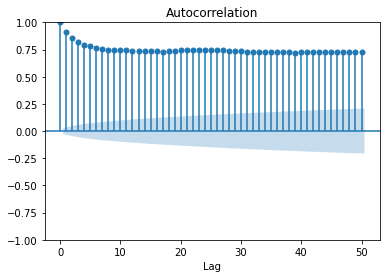

In [164]:
from statsmodels.graphics.tsaplots import plot_acf

# samples is a numpy array containing the samples from the Gibbs sampler
plot_acf(SMT[:,2], lags=50)
plt.xlabel("Lag")
plt.show()

In [273]:
beta = np.ones((m, 3))
j=1011
Yj = np.array(data2.loc[data2.sch_id == j][["stu_mathscore"]])
Xj = np.ones((Yj.shape[0],2))
Xj[:,1] = np.array(data2.loc[data2.sch_id == j][["stu_ses"]]).reshape(Yj.shape[0],)
#beta[d[j]-1,0] = (Xj.T @ Yj)/(Xj.T @ Xj)[0]
#beta[d[j]-1,2] = (Xj.T @ Yj)/(Xj.T @ Xj)[1]
(Xj.T @ Yj)/(Xj.T @ Xj)

array([[  50.81354839, -204.281101  ],
       [  34.94399828,  -10.00595695]])

In [166]:
data2 = pd.read_csv("Scores_with_covariates", sep = " ")

In [415]:
X = data2[["sch_id", "stu_ses"]]
Y = data2[["sch_id", "stu_mathscore"]]
m = len(data2.sch_id.unique())
school = list(data2.sch_id.unique())

d = {}
ind = 1

for key in school:
    d[key] = ind
    ind += 1

S = 1000
BETA = np.zeros((S,m,2))
TH = np.zeros((S,2))
SIGMA = np.zeros((S,2,2))
SIGMA2 = np.zeros(S)

nu0 = 2
eta0 = 2
#mu0 = np.zeros((2))
#vtheta0 = np.eye(2)
#vtheta0 = np.array([[1,0.5], [0.5,1]])
#s20 = 2
#S0 = np.ones((2,2))
#S0 = np.array([[1,0.5], [0.5,1]])

beta = np.ones((m, 2))

for j in school:
    Yj = np.array(data2.loc[data2.sch_id == j][["stu_mathscore"]])
    Xj = np.ones((Yj.shape[0],2))
    Xj[:,1] = np.array(data2.loc[data2.sch_id == j][["stu_ses"]]).reshape(Yj.shape[0],)
    beta[d[j]-1,:] = (np.linalg.inv(Xj.T @ Xj) @ (Xj.T @ Yj)).reshape(2,)

theta = beta.mean(axis = 0).reshape(2,1)
mu0 = beta.mean(axis = 0).reshape(2,)
SIG = np.cov(beta, rowvar = False)

S0 = np.cov(beta, rowvar = False)
vtheta0 = np.cov(beta, rowvar = False)

sv = np.zeros((m))
for j in school:
    Yj = data2.loc[data2.sch_id == j][["stu_mathscore"]]
    sv[d[j]-1] = Yj.var()

sigma2 = sv.mean()
s20 = sv.mean()


for s in range(S):
    
    #theta
    vtheta = np.linalg.inv(np.linalg.inv(vtheta0) + m * np.linalg.inv(SIG)) 
    etheta = vtheta @ (np.linalg.inv(vtheta0) @ mu0 + (m*np.linalg.inv(SIG)) @ np.mean(beta, axis=0))
    theta = np.random.multivariate_normal(etheta, vtheta)
    
    #SIGMA 
    df = eta0 + m
    x = S0
    for j in school: 
        x = x + (beta[d[j]-1,:].T - theta).reshape(2,1) @ (beta[d[j]-1,:] - theta.T).reshape(1,2)
#    x = np.linalg.inv(x)
    SIG = invwishart.rvs(df = df, scale = x)
    
    #beta
    for j in school:
        Yj = np.array(data2.loc[data2.sch_id == j][["stu_mathscore"]])
        Xj = np.ones((Yj.shape[0],2))
        Xj[:,1] = np.array(data2.loc[data2.sch_id == j][["stu_ses"]]).reshape(Yj.shape[0],)
        vbeta = np.linalg.inv(np.linalg.inv(SIG) + ((Xj.T @ Xj)/sigma2))
        ebeta = vbeta@((np.linalg.inv(SIG)@theta).reshape(2,1) + ((Xj.T @ Yj)/sigma2).reshape(2,1)).reshape(2,)
        beta[d[j]-1,:] = np.random.multivariate_normal(ebeta, vbeta)

    
    #sigma 2
    nun = nu0 + data2.shape[0]
    ss = nu0 * s20   
    for j in school:
        Yj = np.array(data2.loc[data2.sch_id == j][["stu_mathscore"]])
        Xj = np.ones((Yj.shape[0],2))
        Xj[:,1] = np.array(data2.loc[data2.sch_id == j][["stu_ses"]]).reshape(Yj.shape[0],)
        for i in range(Xj.shape[0]):
            ss = ss + ((Yj[i] - (beta[d[j]-1,:] @ Xj[i,:].T))**2)
    sigma2 = 1/np.random.gamma(nun/2, 2/ss)
    
    #save results
    BETA[s,:,:] = beta
    TH[s,:] = theta
    SIGMA[s,:,:] = SIG
    SIGMA2[s] = sigma2

In [406]:
beta = np.ones((m, 2))

for j in school:
    Yj = np.array(data2.loc[data2.sch_id == j][["stu_mathscore"]])
    Xj = np.ones((Yj.shape[0],2))
    Xj[:,1] = np.array(data2.loc[data2.sch_id == j][["stu_ses"]]).reshape(Yj.shape[0],)
    beta[d[j]-1,:] = (np.linalg.inv(Xj.T @ Xj) @ (Xj.T @ Yj)).reshape(2,)

np.mean(beta, axis=0)
np.cov(beta.T)

array([[27.80588766,  1.33526853],
       [ 1.33526853, 10.09956134]])

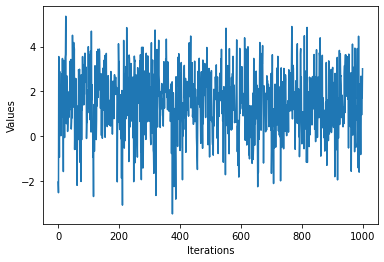

In [416]:
plt.plot(BETA[:,4,1])
plt.xlabel("Iterations")
plt.ylabel("Values")
plt.show()

In [363]:
BETA[:50,:,1]

array([[ 3.15670336,  4.0027438 ,  1.20276096, ...,  3.89064769,
         5.48555863,  2.49281081],
       [ 5.16953161,  3.4200407 ,  1.12463014, ...,  2.8937769 ,
        -0.07227024,  1.21926044],
       [ 4.19000173,  4.87211913, -0.99735716, ...,  3.59933769,
         4.01881975,  2.53791947],
       ...,
       [ 3.16149474,  1.74361017,  3.07219481, ...,  1.77132617,
         3.03252163,  3.02917994],
       [ 2.92399408,  3.4628918 ,  2.17880729, ...,  2.00315083,
         2.25323448,  2.13670536],
       [ 2.47116878,  2.42145604,  1.9826309 , ...,  3.01411401,
         2.74775753,  3.32391815]])

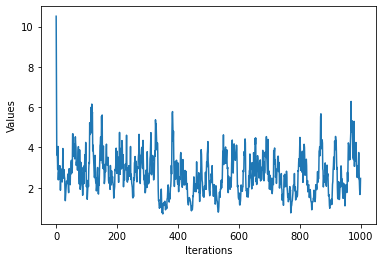

In [417]:
plt.plot(SIGMA[:,1,1])
plt.xlabel("Iterations")
plt.ylabel("Values")
plt.show()

In [321]:
SIGMA[:,0,0]

array([2.57216595e+01, 1.37349056e+02, 8.59848733e+02, 2.34521568e+03,
       4.39109172e+03, 5.96706725e+03, 1.02355408e+04, 8.45572243e+03,
       1.36879043e+04, 1.85284184e+04, 1.89426528e+04, 2.24715470e+04,
       1.87632778e+04, 2.55377756e+04, 2.66216993e+04, 3.38090443e+04,
       2.87959917e+04, 3.90989865e+04, 3.04540816e+04, 3.35389905e+04,
       3.48152460e+04, 4.12712625e+04, 4.40670019e+04, 5.05090732e+04,
       5.97662467e+04, 4.73773501e+04, 5.11111920e+04, 3.90454774e+04,
       7.14326320e+04, 6.55733908e+04, 6.78251651e+04, 6.62115948e+04,
       6.60519225e+04, 5.96882613e+04, 8.22333916e+04, 6.77343383e+04,
       8.70332261e+04, 8.35161271e+04, 8.87501242e+04, 7.84215711e+04,
       7.25012273e+04, 7.95605583e+04, 9.27480805e+04, 9.73897703e+04,
       8.80588585e+04, 9.96113087e+04, 9.51256029e+04, 1.05414848e+05,
       1.39814074e+05, 1.09145916e+05, 1.49692752e+05, 9.94684081e+04,
       9.97497136e+04, 1.13029073e+05, 1.36605435e+05, 1.26981146e+05,
      

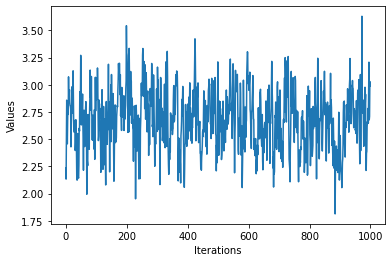

In [418]:
plt.plot(TH[:,1])
plt.xlabel("Iterations")
plt.ylabel("Values")
plt.show()

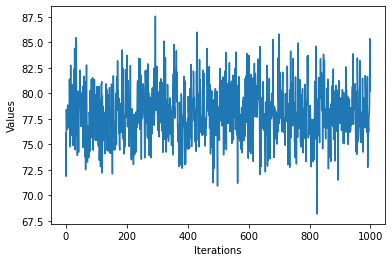

In [419]:
plt.plot(SIGMA2)
plt.xlabel("Iterations")
plt.ylabel("Values")
plt.show()

<AxesSubplot:ylabel='Density'>

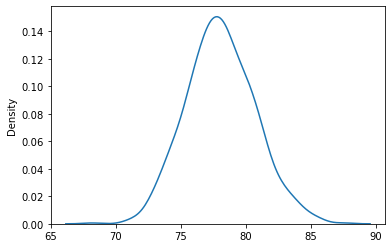

In [421]:
sns.kdeplot(SIGMA2)

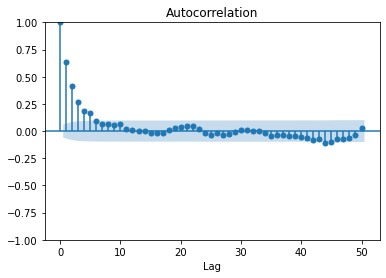

In [420]:
plot_acf(TH[:,1], lags=50)
plt.xlabel("Lag")
plt.show()